# Row 3: At any half hour the live level predicts the next 30 minutes better than the stale print

| field | content |
|---|---|
| frequency (GEX period) | live value at a 30-minute close |
| strength | 0.52 Spearman correlation (stale print 0.43) |
| tradability (1 to 10) | 6 |
| holds for | yes SPY, QQQ (-0.48 versus -0.34), IWM (-0.25 versus -0.18); weak NVDA; no edge in the other six stocks |
| how to trade | refresh the volatility expectation every half hour; scale same-day-expiry premium selling or gamma scalping to the current level |
| numbers (SPY) | joint regression t-statistics -10.6 for the live value versus -1.5 for the stale print; at 14:00 the rest-of-day correlation is -0.54 live versus -0.42 stale |
| example | at 11:30 the live value's correlation with the next hour's range is -0.60, the stale print's -0.52 |
| video opener | Gamma exposure is not a once-a-day number; it changes every time SPY moves, because how much hedging dealers must do depends on where price sits against the strikes people own. Recomputing it every half hour tells you more about the next half hour than the morning print does, and the gap widens all afternoon. A live number is worth more the later in the day it gets. |

In [1]:
import sys
import json
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
sys.path.insert(0, "../gex_history")
import rows as R
import gexlib as G
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
ctx = R.load("spy")
print(ctx["sym"], len(ctx["daily"]), "days")

SPY 751 days


{
 "spearman_live": -0.5179344148479462,
 "spearman_stale": -0.4287268803677415,
 "within_day_increment": -0.03288891991386256,
 "joint_regression_t": {
  "live": -10.593585870512305,
  "stale": -1.4830847419634292
 },
 "n_buckets": 8916,
 "share_days_with_flip": 0.28667563930013457
}


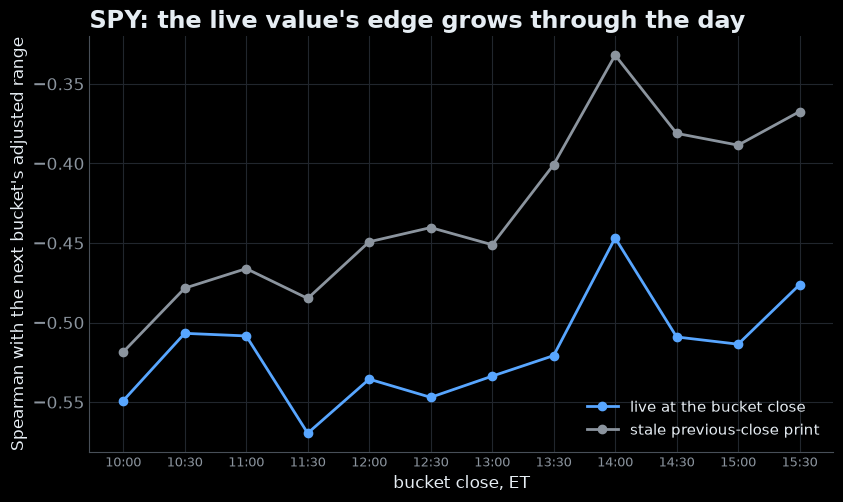

In [2]:
res = R.row3(ctx)
print(json.dumps({k: v for k, v in R.show(res).items() if 'bucket (' not in k}, indent=1))
_ = R.fig3(ctx, res, G.FIGURES / 'row03_next_30_minutes.png')

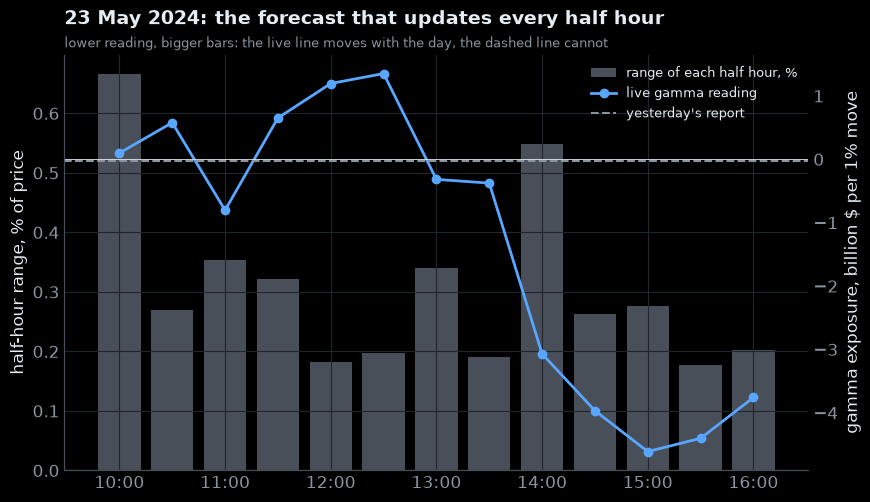

In [3]:
_ = R.fig_open3(ctx, res, G.FIGURES / 'row03_opener.png')   # the video opener, in dollars, percent and dates

In [4]:
R.per_name({'r3_spearman_live': 'Spearman correlation, live', 'r3_spearman_stale': 'Spearman correlation, stale print', 'r3_share_days_flip': 'share of days with an intraday sign flip'}).round(3)

,"Spearman correlation, live","Spearman correlation, stale print",share of days with an intraday sign flip
symbol,,,
SPY,-0.518,-0.429,0.287
QQQ,-0.481,-0.336,0.226
IWM,-0.250,-0.180,0.185
NVDA,-0.132,-0.103,0.105
TSLA,0.006,0.006,0.218
AAPL,-0.129,-0.157,0.036
AMZN,-0.156,-0.159,0.081
META,-0.117,-0.120,0.169
MSFT,-0.123,-0.142,0.125
